### **Credit Card Fraud Detection**

##### **Meritshot Internship Task.**
This project applies **classification techniques**, using historical **credit card transaction data** obtained from Kaggle to predict whether a transaction is **fraudulent or legitimate**. Classification is suitable because the target variable *(Class)* is categorical *(Fraud / Not Fraud)*. The project workflow is as follows;

1. Problem Statement
2. Dataset Description
3. Data Loading
4. Data Overview
5. Data Cleaning
6. Data Preprocessing
7. Feature Engineering
8. Exploratory Data Analysis (EDA) 
9. Model Building
10. Model Evaluation
11. Prediction
12. Insights and Conclusion
---

##### 1. Problem Statement

Credit card fraud is a significant problem in the financial industry, leading to substantial money loss for banks and inconvenience for customers. Fraudulent transactions are rare and often difficult to detect using traditional rule-based systems.

The goal of this project is to build a **machine learning classification model** that can accurately identify fraudulent credit card transactions while minimizing false alarms. This solution helps financial institutions detect fraud early and improve transaction security.

---

#####  2. Dataset Description

The dataset used for this project was obtained from **Kaggle (Credit Card Fraud Detection Dataset)**.

- **Number of rows:** 284,807  
- **Number of columns:** 30  
- **Target variable:** `Class`  

Feature Explanation
- `Class`: Indicates transaction type  
  - 0 → Legitimate transaction  
  - 1 → Fraudulent transaction  
- `V1` to `V28`: PCA-transformed numerical features to protect customer privacy  
- `Time`: Time elapsed in seconds since the first transaction  
- `Amount`: Transaction amount  

The dataset is highly imbalanced, with fraudulent transactions representing a very small portion of the data.

---


##### 3. Data Loading

In [1]:
# importing libaries
import pandas as pd           
import numpy as np 
import seaborn as sns       
import matplotlib.pyplot as plt    
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
# loading the dataset
df = df = pd.read_csv(r"C:\Users\hp\OneDrive\Documents\projects\merishot internship\credit card fraud detection\raw data\archive\creditcard.csv")

##### 4. Data Overview 

In [3]:
# preview of data 
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
# shape of dataset
df.shape

(284807, 31)

###### no missing data found

##### 5. Data Cleaning

In [6]:
# checking for duplicate rows
df.duplicated().sum()

1081

In [7]:
# droping duplicates
df = df.drop_duplicates()

##### 6. Data Preprocessing

In [8]:
# 6.1 feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df[['Time', 'Amount']] = scaler.fit_transform(df[['Time', 'Amount']])

In [ ]:
pip install imbalanced-learn

In [14]:
# 6.2 handling class imbalance (SMOTE)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

df = smote.fit_resample(df)

ModuleNotFoundError: No module named 'imblearn'

##### . Exploratory Data Analysis

In [ ]:
# summary statistics 
df.describe()l;l;

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


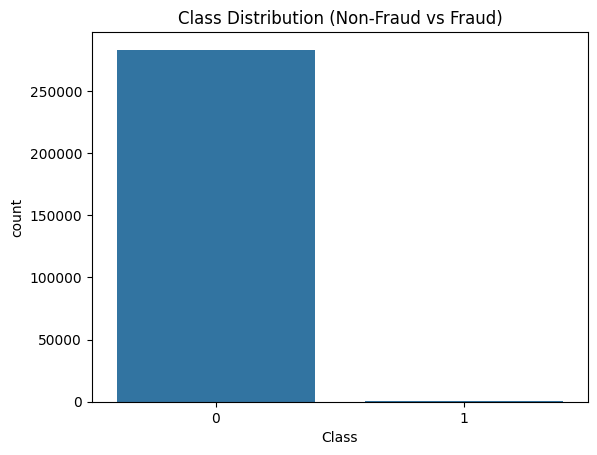

In [ ]:
# 6.1 Class Distribution
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (Non-Fraud vs Fraud)")
plt.show()

###### 6.1 Class Distribution
######  - The dataset is **highly imbalanced**, with legitimate transactions making up ~99.83% of the data and fraudulent transactions only ~0.17%.  
###### - Visualization (bar chart) clearly shows that fraud cases are extremely rare.

###### **Insight:**  
###### - Accuracy alone is misleading; a naive model predicting all transactions as legitimate would have ~99.8% accuracy.  
###### - This highlights the importance of **precision, recall, and F1-score** for evaluation.

In [ ]:
# 6.2 Transaction Amount Distribution
plt.figure(figsize=(10,5))
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, alpha=0.7, label='Legit', color='blue')
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, alpha=0.7, color='red')
plt.yscale('log')
plt.xlabel('Transactional Amount')
plt.ylabel('nn')
plt.legend()
plt.title("Transaction Amount Distribution")
plt.show()

NameError: name 'plt' is not defined

###### 6.2 Transaction Amount Analysis
###### - Histograms comparing `Amount` for fraud vs legitimate transactions show:
######  - Fraudulent transactions often have **irregular amounts**.
######  - Some fraud cases involve **very high transaction amounts**, while others are small.  

###### **Insight:**  
###### - Transaction amount can be a **useful predictor**, but alone it is not sufficient to detect fraud reliably.  
###### - Scaling the `Amount` feature is necessary for effective model training.

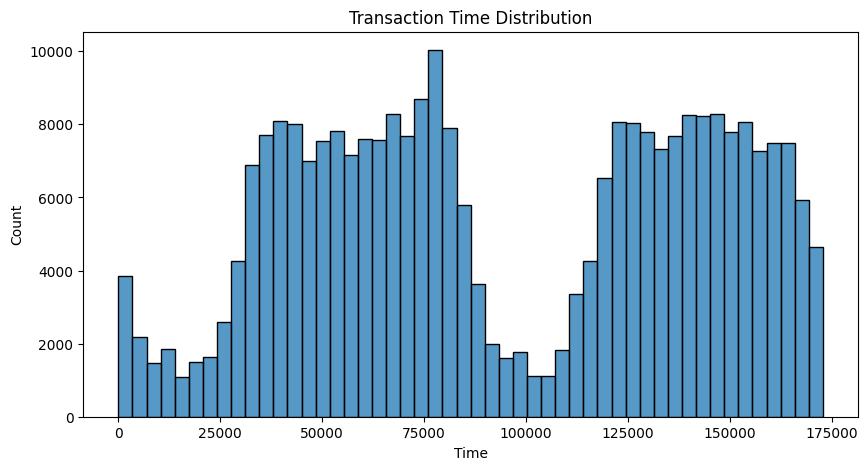

In [ ]:
# 6.3 Time Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Time'], bins=50)
plt.title("Transaction Time Distribution")
plt.show()